In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset (adjust the path if your dataset directory differs slightly)
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv', encoding='latin-1')

# Keep only the necessary columns and rename them for clarity
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Map labels to binary values for the model (0 = Legitimate/Ham, 1 = Spam)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Verify the changes
df.head()


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Split the data

In [7]:
# Split features and target variable
X = df['message']
y = df['label']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Extraction using TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer and remove common English stop words (like 'the', 'is', 'in')
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit on training data and transform it
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform testing data (DO NOT fit here)
X_test_tfidf = vectorizer.transform(X_test)

# Train the Model

In [9]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train the model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

# Evaluate Performance

Accuracy: 0.9721973094170404

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



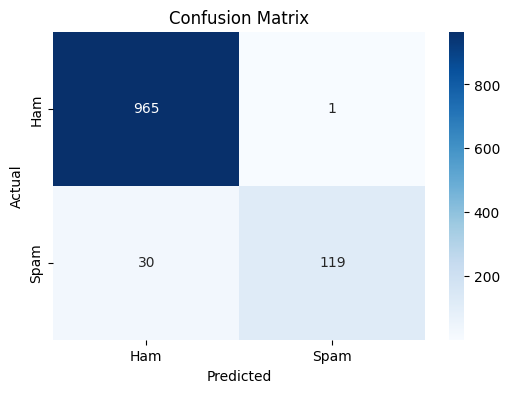

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions
y_pred = nb_model.predict(X_test_tfidf)

# Print metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [11]:
import joblib

# Save the trained Naive Bayes model
joblib.dump(nb_model, 'spam_classifier_model.pkl')

# Save the fitted TF-IDF vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
